Exploratory Data Analysis (EDA) on retail sales dataset  

Internship - Oasis Infobyte (OIBSIP)  
Project 1, Proposal Level 1    
Author - Aniket Mishra

Objective -  

The Objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset. The analysis aims to focuses on loading and cleaning the data, performing descriptive statistical analysis aand uncover patterns, trends and insights that can help the retail business make informed decisions.

Understanding the Dataset -  

The retail sales dataset contains information about customer purchases made in a retail store. Each row represents a single sales transaction and includes details such as the transaction ID, purchase date, customer ID, etc.

In [1]:
# Importing Libraries

import pandas as pd      #for data manipulation
import numpy as np      #for numerical calculations
import matplotlib.pyplot as plt      #for basic plotting
import seaborn as sns      #for statistical visualizations

plt.style.use("ggplot")

In [2]:
# Loading Dataset

df = pd.read_csv("D:/Downloads/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Observation -  

The dataset was successfully loaded.  
The first five rows were displayed to understand the dataset structure.

In [3]:
# Exploring Dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


Observation -  

Exploring the dataset gives a clear overview of the data before performing cleaning and analysis. We can see the type of data stored in each column and whether there are any missing values. 

In [4]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Observation -  

We can see a summary of the numerical data in the dataset.
Since `50%`(median) of transactions are `135` or less while the `average`(mean) is `456`, so a few high-value purchases are increasing the average.

In [5]:
# Checking Missing Values

df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Observation -  

No missing values were found in the dataset, therefore, no data cleaning is required.

In [6]:
# Checking Duplicate Values

df.duplicated().sum()

np.int64(0)

Observation -  

No duplicate values were found in the dataset, therefore, no duplicate records needed to be dropped.

In [7]:
# Descriptive Statistics

df.mean(numeric_only = True)

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Observation -  

Mean represents the average value. It helps understand the average customer age, quantity purchased and spending.  
Since the dataset contains both numerical and text columns like `Gender` and `Product Category`, therefore, `numeric_only=True` is used.  
The average price per unit is around 180, suggesting customers mostly purchase moderately priced products. 

In [8]:
df.median(numeric_only = True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Observation -  

Median represents the middle value. It is useful because it's less affected by extreme values.

In [9]:
df.mode().iloc[0]

Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              50.0
Name: 0, dtype: object

Observation -  

Mode represents the most frequently occurring value. It helps identify the most common product category or customer gender.

In [10]:
df.std(numeric_only = True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

Observation -  

Standard deviation measures the spread of the data. A higher value indicates greater variation.  
The standard deviation of Total Amount is high, which shows that sales vary considerably between transactions.

In [11]:
# Convert Date Column

df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


Observation -  

The Date column is converted into a date and time format so that it can be easily analyzed. 

In [12]:
# Time Series Analysis

monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()
monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

Observation -  

The dataset was grouped by month to calculate the total sales for each month. It helps identify which months had higher or lower sales and provides a clear overview of the monthly sales trend.

In [13]:
monthly_sales.index = monthly_sales.index.astype(str)

Observation -  

The period index was converted into strings for easier graph plotting.

Observation -  

The sales data was grouped month wise. This allows us to analyse how sales changed every month.

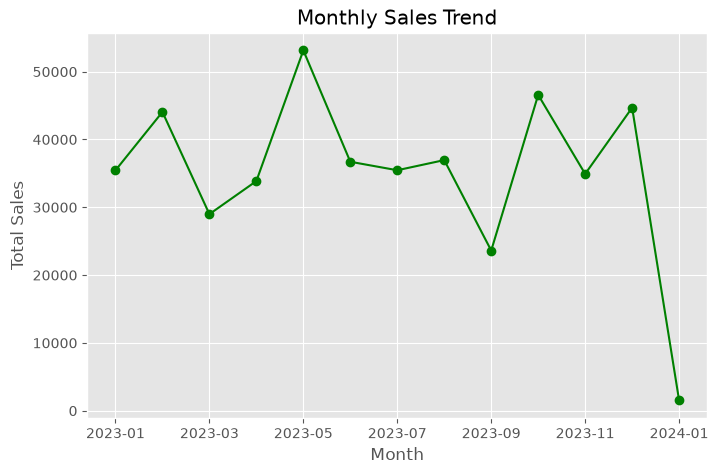

In [14]:
# Visualization

monthly_sales.plot(figsize=(8,5), marker = "o", color = "green")
plt.title("Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

Observation -   

The line graph shows how total sales changed from month to month. `X-axis` shows each `Month`, where as, `Y-axis` shows the `Total Sales` amount for each month.  

The month with the highest total sales is `2023-05` and the month with the lowest total sales is `2024-01`.  

Sales did not remain the same throughout the year. Some months recorded higher sales, while others had lower sales, indicating fluctuations in customer purchases. The last month shows a sharp decline in total sales, which may be due to fewer recorded transactions or incomplete data for that month.

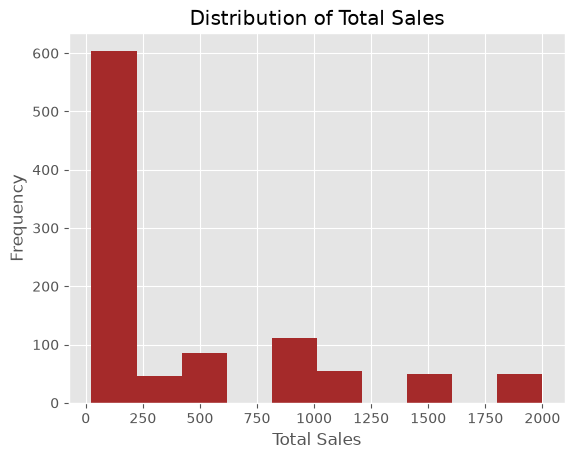

In [15]:
plt.hist(df["Total Amount"], color = "brown")
plt.title("Distribution of Total Sales")

plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

Observation -    

Most transactions have lower sales amounts, as shown by the long bars on the left side. As the sales amount increases, the number of transactions decreases. This shows that high value sales are less common than low value sales.  

`X-axis` shows the sales amount of each transaction, where as, `Y-axis` shows how many transactions happen within each sales amount range.  

Most customers made low value purchases. Only a small number of transactions had high sales amounts.

In [16]:
# Customer Analysis

df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

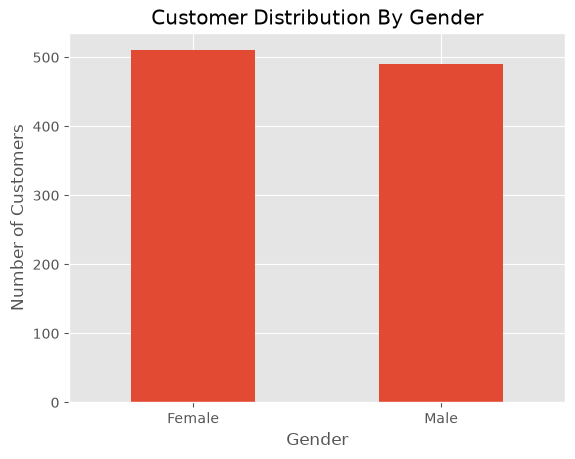

In [17]:
df["Gender"].value_counts().plot(kind="bar")
plt.title("Customer Distribution By Gender")

plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation = 0)
plt.show()

Observation -    

The graph compares the `Number of Male and Female Customers`. The number of female customers is slightly higher than the number of male customers.  

`X-axis` shows the male and female `Customer Categories` , where as, `Y-axis` shows the `Number of Customers` in each gender category.  

Overall, the customer distribution is fairly balanced, indicating that both genders contribute almost equally to retail sales.

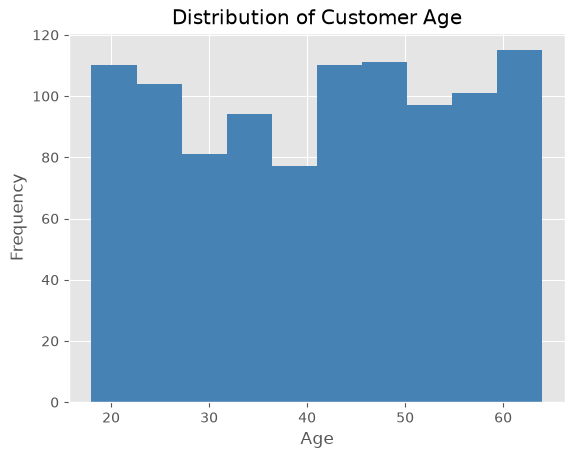

In [18]:
plt.hist(df["Age"], color = "steelblue")
plt.title("Distribution of Customer Age")

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Observation -  

The graph shows the `Age Distribution of Customers`. Since the bars have similar heights, it shows that customers are evenly distributed across the age groups. No single age group dominates.  

`X-axis` shows the `Age of Customers`, where as, `Y-axis` shows the `Number of Customers` in each age range.  

In [19]:
# Product Analysis

df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

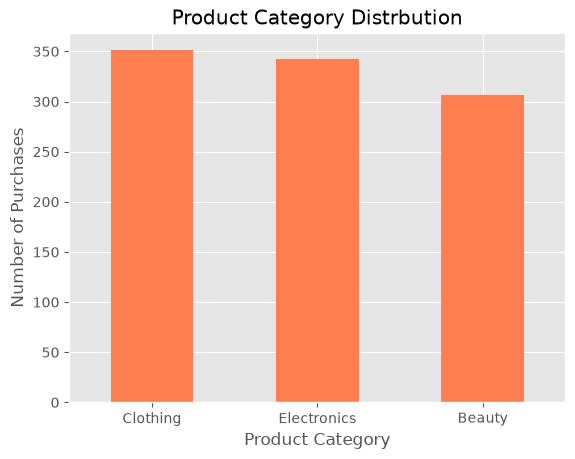

In [20]:
df["Product Category"].value_counts().plot(kind="bar", color = "coral")
plt.title("Product Category Distrbution")

plt.xlabel("Product Category")
plt.ylabel("Number of Purchases")
plt.xticks(rotation = 0)
plt.show()

Observation -  

The graph shows the number of purchases across different product categories. `X-axis` shows the `Product Categories` (Clothing, Electronics, Beauty), whereas, `Y-axis` shows the `Times the Products are Purchased` across categories.  

Clothing has the highest number of purchases, followed by Electronics, while Beauty has the lowest. The difference between the categories is small. Overall, the sales are fairly balanced across all three categories.

In [21]:
# Sales Analysis

df.groupby("Product Category")["Total Amount"].sum()

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

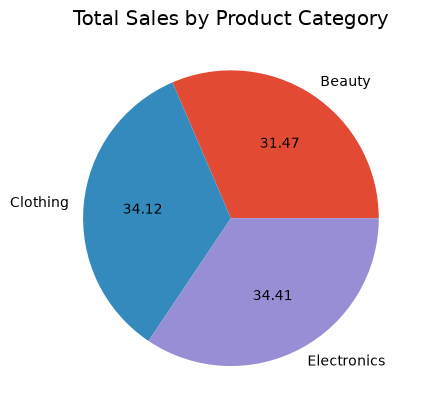

In [22]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

plt.title("Total Sales by Product Category")
plt.pie(category_sales, labels = category_sales.index, autopct = "%.2f")
plt.show()

Observation -  

The Pie chart shows the percentage of `Total Sales` generated by each `Product Category`.   

`Electronics` contributes the highest share around `34.4%`, followed closely by `Clothing` around `34.1%`. `Beauty` contributes the lowest share around `31.5%`. The difference between the categories is small, which shows that sales are fairly distributed across all three product categories.

Insights -  

1. The dataset was clean and ready for analysis after handling missing values and checking data types.  
2. Monthly sales changed over time, showing that sales were not the same every month.  
3. Most sales were of low value transactions, while only a few transactions had very high sales amounts.  
4. The number of male and female customers was almost equal, showing a balanced customer base.  
5. Customers belonged to different age groups, showing that people of various ages purchased with no paticular age group dominating.  
6. Clothing, Electronics and Beauty were purchased in similar numbers, though Electronics generated the highest share of total sales and Beauty the lowest.

Recommendations -  

1. Increase marketing and discount offers during months with lower sales to improve revenue.  
2. Continue focusing on Electronics and Clothing, as they contribute the highest sales.  
3. Introduce offers or discounts on Beauty products to increase their sales.  
4. Since the maximum total amount is 2000, premium customers should be identified and rewarded with loyalty programs or exclusive offers.  
5. The large difference between the minimum and maximum sales amount shows that customers have different spending habits. Therefore, the store should  offer products at different price ranges.  
6. Since both male and female customers purchase in similar numbers, create marketing campaigns for both groups.

Conclusion -  

This Exploratory Data Analysis (EDA) helped understand customer behavior, sales trends and product performance. The analysis showed that sales fluctuate across months, customers are well distributed by gender and age, and Electronics contributes the highest share of total sales. These insights can help the business improve marketing strategies, manage inventory more effectively and make better business decisions.